## Revenue and Profit Impact Analysis

## Objectives

1. Load the customer-level RFM and segment data produced by `segmentation.ipynb`.
2. Quantify how much of total revenue and margin each segment actually contributes.
3. Run a Pareto (80/20) check: how concentrated is revenue among the top customers?
4. Estimate the size of the opportunity in re-engaging the At Risk / Low Engagement segment, since it's the largest group by customer count.
5. Summarise the findings in business terms: where should marketing and retention spend actually go?

In [1]:
%matplotlib inline

# Core Python utilities
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

# Data manipulation
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns

# Pandas display settings: readable but not noisy
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 60)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

# Plot settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11


In [2]:
%%capture
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Processed data folder:", PROCESSED_DATA_DIR)
print("Reports folder:", REPORTS_DIR)

### Load Segment Data

In [4]:
segments = pd.read_csv(PROCESSED_DATA_DIR / "customer_segments.csv")

print(f"Customers: {segments.shape[0]:,}")
segments.head()

Customers: 250


,customer_id,recency,frequency,monetary,margin,cluster,segment
0,CUST0001,11,8,"24,889.49","15,626.78",1,Loyal High-Value
1,CUST0002,637,1,"1,817.79","1,171.71",0,Churned / Lost
2,CUST0003,220,10,"31,189.17","20,950.93",1,Loyal High-Value
3,CUST0004,129,3,"9,056.97","5,565.20",2,At Risk / Low Engagement
4,CUST0005,8,7,"19,044.42","11,248.30",1,Loyal High-Value


## 1. Revenue and Margin Contribution by Segment


,monetary,margin,customer_count,revenue_share,margin_share
segment,,,,,
Loyal High-Value,"1,416,268.33","821,103.54",62,44.90,47.40
Active / Growing,"1,054,753.36","558,890.61",75,33.50,32.30
At Risk / Low Engagement,"579,971.33","302,819.37",85,18.40,17.50
Churned / Lost,"101,657.73","49,238.73",28,3.20,2.80


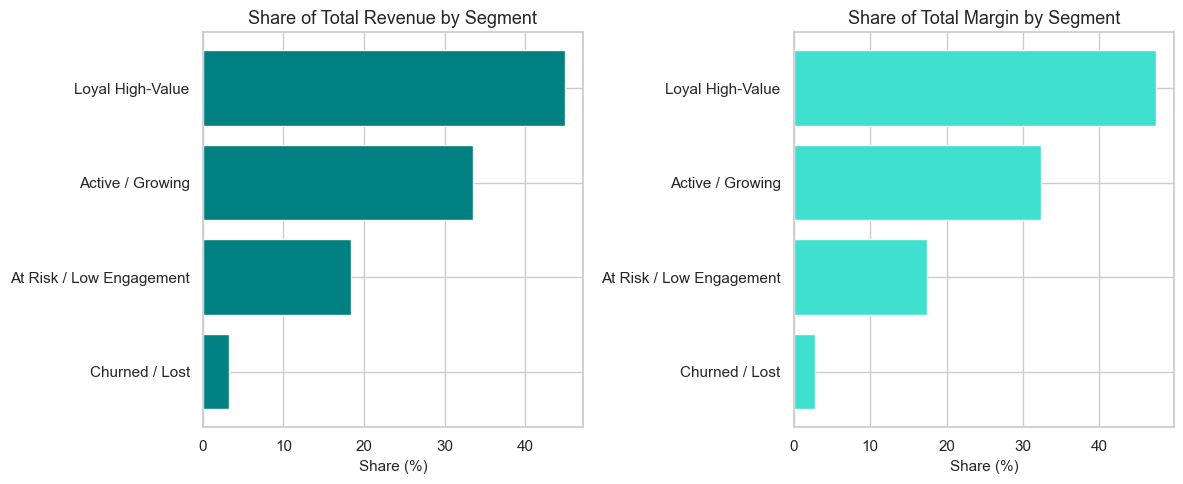

In [5]:
segment_totals = segments.groupby("segment")[["monetary", "margin"]].sum()
segment_totals["customer_count"] = segments["segment"].value_counts()
segment_totals["revenue_share"] = (segment_totals["monetary"] / segment_totals["monetary"].sum() * 100).round(1)
segment_totals["margin_share"] = (segment_totals["margin"] / segment_totals["margin"].sum() * 100).round(1)
segment_totals = segment_totals.sort_values("monetary", ascending=False)

display(segment_totals)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

order = segment_totals.index
axes[0].barh(order, segment_totals["revenue_share"], color="#008080")
axes[0].set_title("Share of Total Revenue by Segment")
axes[0].set_xlabel("Share (%)")
axes[0].invert_yaxis()

axes[1].barh(order, segment_totals["margin_share"], color="#40E0D0")
axes[1].set_title("Share of Total Margin by Segment")
axes[1].set_xlabel("Share (%)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## How Concentrated Is Revenue?

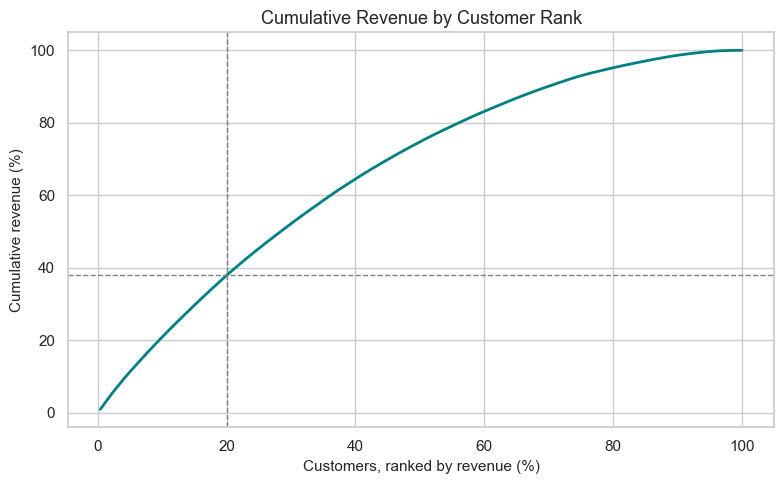

Top 20% of customers (50 of 250) generate 37.9% of total revenue.


In [6]:
ranked = segments.sort_values("monetary", ascending=False).reset_index(drop=True)
ranked["customer_rank_pct"] = (ranked.index + 1) / len(ranked) * 100
ranked["cumulative_revenue_pct"] = ranked["monetary"].cumsum() / ranked["monetary"].sum() * 100

top_20_pct_customers = int(len(ranked) * 0.2)
revenue_from_top_20_pct = ranked.loc[:top_20_pct_customers - 1, "monetary"].sum() / ranked["monetary"].sum() * 100

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ranked["customer_rank_pct"], ranked["cumulative_revenue_pct"], color="#008080", linewidth=2)
ax.axvline(20, color="grey", linestyle="--", linewidth=1)
ax.axhline(revenue_from_top_20_pct, color="grey", linestyle="--", linewidth=1)
ax.set_title("Cumulative Revenue by Customer Rank")
ax.set_xlabel("Customers, ranked by revenue (%)")
ax.set_ylabel("Cumulative revenue (%)")

plt.tight_layout()
plt.show()

print(f"Top 20% of customers ({top_20_pct_customers} of {len(ranked)}) generate {revenue_from_top_20_pct:.1f}% of total revenue.")

## 3. The At Risk / Low Engagement Opportunity.

In [7]:
segment_avg = segments.groupby("segment")[["monetary", "margin"]].mean().round(2)
segment_avg["customer_count"] = segments["segment"].value_counts()
display(segment_avg)

at_risk = segment_avg.loc["At Risk / Low Engagement"]
active = segment_avg.loc["Active / Growing"]

margin_gap_per_customer = active["margin"] - at_risk["margin"]
potential_margin_uplift = margin_gap_per_customer * at_risk["customer_count"]

print(f"Average margin gap per customer (Active/Growing vs At Risk): {margin_gap_per_customer:,.2f}")
print(f"If every At Risk customer moved to Active/Growing's average margin, "
      f"potential margin uplift: {potential_margin_uplift:,.2f} across {int(at_risk['customer_count'])} customers")
print("This is an illustrative ceiling, not a forecast - it assumes full conversion, which re-engagement campaigns rarely achieve in full.")

,monetary,margin,customer_count
segment,,,
Active / Growing,"14,063.38","7,451.87",75
At Risk / Low Engagement,"6,823.19","3,562.58",85
Churned / Lost,"3,630.63","1,758.53",28
Loyal High-Value,"22,843.04","13,243.61",62


Average margin gap per customer (Active/Growing vs At Risk): 3,889.29
If every At Risk customer moved to Active/Growing's average margin, potential margin uplift: 330,589.65 across 85 customers
This is an illustrative ceiling, not a forecast - it assumes full conversion, which re-engagement campaigns rarely achieve in full.


## Conclusion

I quantified what each segment is actually worth, not just how it looks on paper. Loyal High-Value customers, only 25% of the customer base, contribute the largest share of both revenue and margin - confirming that segment as the one to protect first. Revenue is meaningfully concentrated: the top 20% of customers by spend account for a disproportionate share of total revenue, which is the kind of concentration that makes VIP treatment for the top segment worth the investment.

The At Risk / Low Engagement segment is the most interesting from a growth standpoint - not because those customers are the most valuable individually, but because there are 85 of them, the largest group in the base. I calculated an illustrative ceiling: if every At Risk customer were moved up to the Active/Growing segment's average margin, the potential margin uplift is substantial, purely because of the size of the group. That's not a forecast, since full conversion is unrealistic, but it does show where re-engagement spend has the most leverage - not on the smallest, already-loyal segment, but on the largest underperforming one.

Put simply: protect the Loyal High-Value segment, because it is disproportionately valuable and revenue is concentrated there. But the biggest opportunity for growth sits in the At Risk / Low Engagement segment, purely on volume.